# Analisis Deep Learning - Deteccion de Fraude\n
\n
Este notebook revisa los artefactos generados por `src/dl/train_dl.py`: curvas de entrenamiento, metricas, comparacion con ML y ejemplos de predicciones correctas e incorrectas.

In [48]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.settings import REPORTS_DIR

REPORTS = REPORTS_DIR
REPORTS

WindowsPath('C:/Users/cgalv/source/Python/AI/clase1/Proyecto-AI/data/reports')

## Curvas de entrenamiento y validacion

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
epoch,,,,,,,,,,,
10,0.987688,0.998268,0.047751,0.771057,0.991740,0.991281,0.999350,0.033399,0.831804,0.997067,0.0010
11,0.988312,0.998253,0.045832,0.780466,0.991548,0.992125,0.999342,0.030527,0.845771,0.997067,0.0010
12,0.990273,0.998464,0.042325,0.810667,0.992701,0.994344,0.999353,0.026259,0.887869,0.992669,0.0005
13,0.990539,0.998540,0.040957,0.815212,0.992317,0.993469,0.999397,0.027699,0.869482,0.996334,0.0005
14,0.991437,0.998565,0.037723,0.829856,0.993085,0.987188,0.998468,0.056742,0.770102,0.997067,0.0005


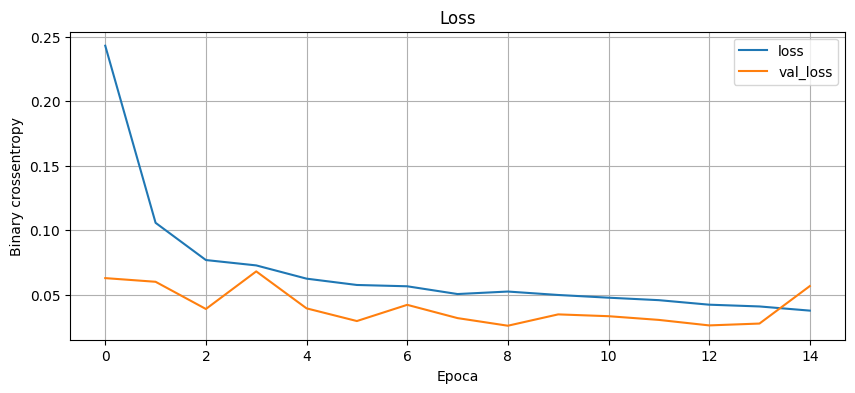

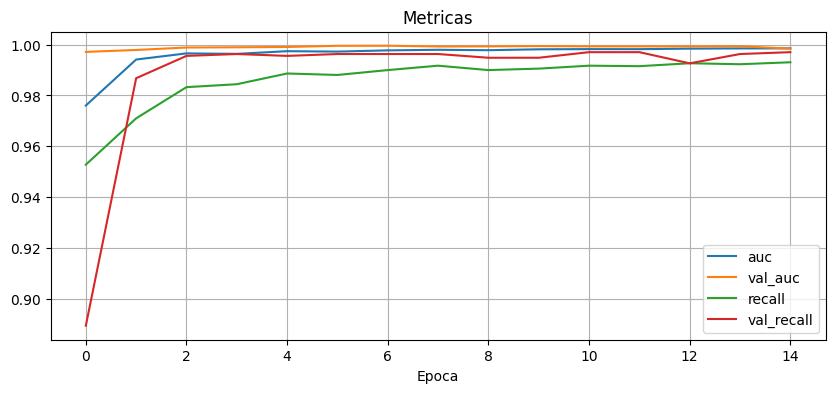

In [49]:
history_path = REPORTS / 'dl_training_history.csv';

if history_path.exists():
    history = pd.read_csv(history_path, index_col='epoch');
    display(history.tail());

    axes = history[['loss', 'val_loss']].plot(figsize=(10, 4), grid=True, title='Loss');
    axes.set_xlabel('Epoca');
    axes.set_ylabel('Binary crossentropy');
    plt.show();

    metric_cols = [c for c in ['auc', 'val_auc', 'recall', 'val_recall'] if c in history.columns];
    if metric_cols:
        ax = history[metric_cols].plot(figsize=(10, 4), grid=True, title='Metricas')
        ax.set_xlabel('Epoca')
        plt.show()
else:
    print('Aun no existe dl_training_history.csv. Ejecuta: python src/dl/train_dl.py')

## Metricas finales del modelo DL

In [50]:
metrics_path = REPORTS / 'dl_metrics.json'

if metrics_path.exists():
    with metrics_path.open() as f:
        metrics = json.load(f)
    display(pd.Series(metrics, name='deep_learning_mlp').to_frame())
else:
    print('Aun no existe dl_metrics.json.')

,deep_learning_mlp
accuracy,0.9891
precision,0.7936
recall,0.9945
f1,0.8828
roc_auc,0.9995
avg_precision,0.9933


## Comparacion con modelos de Machine Learning

,accuracy,precision,recall,f1,roc_auc,avg_precision
deep_learning_mlp,0.9891,0.7936,0.9945,0.8828,0.9995,0.9933


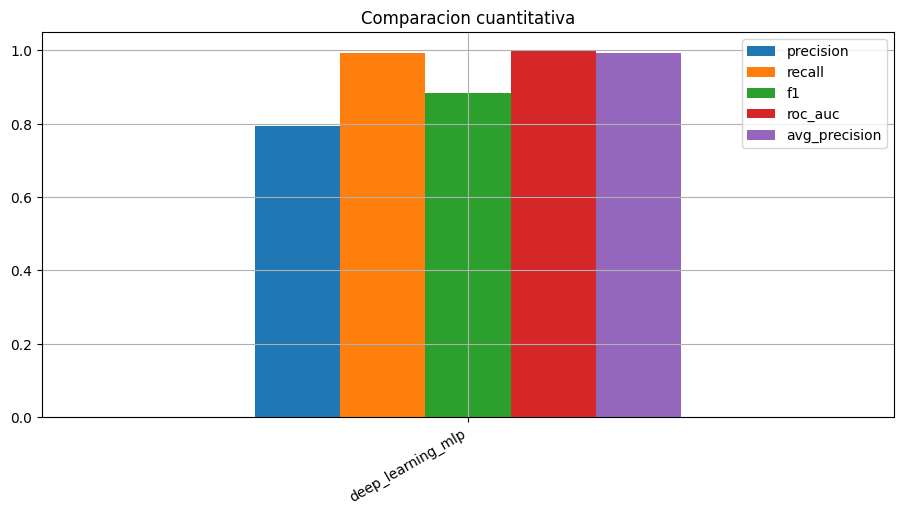

In [51]:
comparison_path = REPORTS / 'model_comparison.csv'

if comparison_path.exists():
    comparison = pd.read_csv(comparison_path, index_col=0)
    display(comparison.sort_values('f1', ascending=False))

    metric_subset = [c for c in ['precision', 'recall', 'f1', 'roc_auc', 'avg_precision'] if c in comparison.columns]
    comparison[metric_subset].plot(kind='bar', figsize=(11, 5), grid=True, title='Comparacion cuantitativa')
    plt.xticks(rotation=30, ha='right')
    plt.ylim(0, 1.05)
    plt.show()
else:
    print('Aun no existe model_comparison.csv. Ejecuta primero los scripts de evaluacion.')

## Ejemplos de predicciones correctas e incorrectas

In [52]:
examples_path = REPORTS / 'dl_prediction_examples.csv'

if examples_path.exists():
    examples = pd.read_csv(examples_path)
    display(examples.groupby('result_type').size().rename('count').to_frame())
    display(examples.sort_values(['result_type', 'fraud_probability'], ascending=[True, False]).head(20))
else:
    print('Aun no existe dl_prediction_examples.csv.')

,count
result_type,
false_negative,8
false_positive,8
true_negative,8
true_positive,8


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceOrig,errorBalanceDest,origBalanceZero,amountToOrigRatio,isHighRiskType,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,actual,predicted,fraud_probability,result_type
24,-1.621745,-0.062176,-0.295751,-0.285417,-0.310958,-0.280531,-0.020626,-0.129164,1,0.213564,1,False,True,False,False,False,1,0,0.018410,false_negative
25,-1.594797,-0.101526,-0.295751,-0.285417,-0.301448,-0.278027,-0.073065,-0.144357,1,0.152479,1,False,True,False,False,False,1,0,0.017159,false_negative
26,-1.554375,0.339254,-0.295751,-0.285417,-0.000284,0.095652,0.514327,-0.144357,1,0.836722,1,False,True,False,False,False,1,0,0.016841,false_negative
27,-1.426372,-0.147164,-0.295751,-0.285417,-0.239609,-0.230969,-0.133883,-0.144357,1,0.081633,1,False,True,False,False,False,1,0,0.012539,false_negative
28,-1.668904,-0.122179,-0.294194,-0.285417,-0.314266,-0.294344,-0.107946,-0.144357,1,-0.132639,1,False,True,False,False,False,1,0,0.011871,false_negative
29,-1.574586,-0.236487,-0.295751,-0.285417,0.055680,0.021767,-0.252916,-0.144357,1,-0.057027,1,False,True,False,False,False,1,0,0.009566,false_negative
30,-0.422556,-0.003038,-0.295751,-0.285417,-0.314266,-0.268379,0.058183,-0.144357,1,0.305367,1,False,True,False,False,False,1,0,0.006173,false_negative
31,-0.274342,0.072584,-0.295751,-0.285417,-0.314266,-0.251898,0.158957,-0.144357,1,0.422758,1,False,True,False,False,False,1,0,0.006041,false_negative
8,0.992217,0.256994,-0.143410,-0.285417,0.197323,0.259882,-0.315357,-0.144357,1,-0.132693,1,False,True,False,False,False,0,1,0.998425,false_positive
9,0.850739,0.081392,-0.192565,-0.285417,-0.025323,0.016373,-0.317030,-0.144357,1,-0.132693,1,False,True,False,False,False,0,1,0.997173,false_positive


## Analisis de errores

En este dominio los falsos negativos son el caso mas critico, porque representan fraudes que el sistema deja pasar. Los falsos positivos tambien importan, pero su costo principal es friccion para el usuario. Si el modelo DL obtiene buen ROC-AUC pero bajo recall, conviene revisar el umbral de decision en vez de asumir que la arquitectura fallo.